---
## Part 1 — Environment Setup & Data Preparation


In [ ]:
#1. Connecting the drive with KITTI dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#2. Cloning into OpenPCDet which is from mmdetection and helps us run the pre-trained PointRCNN library
import os

if not os.path.exists('OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git
%cd OpenPCDet

Cloning into 'OpenPCDet'...
remote: Enumerating objects: 4175, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4175 (delta 0), reused 0 (delta 0), pack-reused 4170 (from 2)
Receiving objects: 100% (4175/4175), 4.21 MiB | 18.65 MiB/s, done.
Resolving deltas: 100% (2448/2448), done.
/content/OpenPCDet


In [ ]:
#3. Setting up the environment for execution of the mmdet library
import os

print("1. Installing CUDA 11.8...")
!apt-get update > /dev/null
!apt-get install -y cuda-toolkit-11-8 > /dev/null
os.environ["CUDA_HOME"] = "/usr/local/cuda-11.8"

print("\n2. Installing PyTorch cu118...")
!pip install torch==2.2.1 torchvision==0.17.1 torchaudio==2.2.1 --index-url https://download.pytorch.org/whl/cu118 > /dev/null

print("\n3. Installing spconv and cumm...")
!pip uninstall -y spconv spconv-cu118 cumm cumm-cu118 > /dev/null
!pip install --upgrade cumm-cu118 spconv-cu118 > /dev/null

# Disable JIT to prevent compilation errors
os.environ["SPCONV_DISABLE_JIT"] = "1"
os.environ["CUMM_DISABLE_JIT"] = "1"

print("\n4. Setting up OpenPCDet...")
if not os.path.exists('/content/OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git

!pip install tensorboardX easydict pyyaml scikit-image tqdm SharedArray numba > /dev/null
!cd /content/OpenPCDet && pip install av2 && pip install -r requirements.txt > /dev/null
!cd /content/OpenPCDet && python setup.py develop

# Fix for NumPy 2.0 compatibility issues - enforced at the end
print("\nInstalling compatible NumPy version (1.26.4)...")
!pip install "numpy<2.0.0" --force-reinstall > /dev/null
!pip install open3d
print("\n5. Testing spconv import...")
import spconv
print("spconv installed successfully! Version:", spconv.__version__)

1. Installing CUDA 11.8...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%

2. Installing PyTorch cu118...

3. Installing spconv and cumm...

4. Setting up OpenPCDet...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━


5. Testing spconv import...
spconv installed successfully! Version: 2.3.8


In [ ]:
#4. Setting up the dataset symlink
import os
import shutil

# Replace 'path_to_kitti' with your actual path in Drive
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
local_kitti_path = '/content/OpenPCDet/data/kitti'

os.makedirs('/content/OpenPCDet/data', exist_ok=True)

# Remove existing local_kitti_path if it's not a symlink or if it's a broken symlink
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path) or os.path.isdir(local_kitti_path):
        print(f"Removing existing {local_kitti_path}")
        if os.path.islink(local_kitti_path):
            os.unlink(local_kitti_path)
        else:
            shutil.rmtree(local_kitti_path)

# Create a new symlink
if not os.path.exists(local_kitti_path):
    os.symlink(drive_kitti_path, local_kitti_path)
    print("Symlink created for KITTI dataset.")
else:
    print("KITTI dataset path already exists and is valid.")

# Verify the symlink content by listing some directories
print(f"Verifying contents of {local_kitti_path}/training:")
if os.path.exists(os.path.join(local_kitti_path, 'training')):
    print(os.listdir(os.path.join(local_kitti_path, 'training')))
else:
    print(f"Directory not found: {local_kitti_path}/training")

Removing existing /content/OpenPCDet/data/kitti
Symlink created for KITTI dataset.
Verifying contents of /content/OpenPCDet/data/kitti/training:
['calib', 'label_02', 'image_02', 'velodyne']


In [ ]:
#5. Convert KITTI tracking format to detection format
import os
import glob
import shutil
from tqdm import tqdm

# Paths
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
src_base = '/content/OpenPCDet/data/kitti_tracking'
dst_base = '/content/OpenPCDet/data/kitti_det_format'

# Create a stable symlink for the original tracking data
if not os.path.exists(src_base):
    if os.path.islink(src_base):
        os.unlink(src_base)
    os.symlink(drive_kitti_path, src_base)

# Clean up destination to avoid messy states from previous runs
if os.path.exists(dst_base):
    shutil.rmtree(dst_base)
os.makedirs(dst_base, exist_ok=True)
os.makedirs(os.path.join(dst_base, 'ImageSets'), exist_ok=True)

def process_tracking_label(label_path, dst_label_dir, seq_id):
    with open(label_path, 'r') as f:
        lines = f.readlines()

    frame_dict = {}
    for line in lines:
        parts = line.strip().split(' ')
        if len(parts) < 15: continue

        frame_idx = int(parts[0])
        det_line = ' '.join([parts[2]] + parts[3:]) + '\n'

        if frame_idx not in frame_dict:
            frame_dict[frame_idx] = []
        frame_dict[frame_idx].append(det_line)

    for frame_idx, det_lines in frame_dict.items():
        global_idx = f"{int(seq_id):04d}{frame_idx:04d}"
        out_path = os.path.join(dst_label_dir, f"{global_idx}.txt")

        # OpenPCDet bug fix: DontCare objects MUST be at the bottom of the file
        det_lines.sort(key=lambda x: 1 if x.startswith('DontCare') else 0)

        with open(out_path, 'w') as f:
            f.writelines(det_lines)

def convert_tracking_to_detection(split='training'):
    print(f"Converting {split} set...")
    src_split = os.path.join(src_base, split)
    dst_split = os.path.join(dst_base, split)

    src_velo = os.path.join(src_split, 'velodyne')
    src_image = os.path.join(src_split, 'image_02')
    src_calib = os.path.join(src_split, 'calib')
    src_label = os.path.join(src_split, 'label_02')

    dst_velo = os.path.join(dst_split, 'velodyne')
    dst_image = os.path.join(dst_split, 'image_2')
    dst_calib = os.path.join(dst_split, 'calib')
    dst_label = os.path.join(dst_split, 'label_2')

    for d in [dst_velo, dst_image, dst_calib, dst_label]:
        os.makedirs(d, exist_ok=True)

    if not os.path.exists(src_velo):
        print(f"Source velodyne not found: {src_velo}")
        return

    seqs = sorted(os.listdir(src_velo))

    train_frames = []
    val_frames = []

    for seq in tqdm(seqs, desc=f"Processing {split} sequences"):
        if not os.path.isdir(os.path.join(src_velo, seq)): continue

        # First extract known labels
        if split == 'training' and os.path.exists(os.path.join(src_label, f"{seq}.txt")):
            process_tracking_label(os.path.join(src_label, f"{seq}.txt"), dst_label, seq)

        velo_files = sorted(glob.glob(os.path.join(src_velo, seq, '*.bin')))
        for vf in velo_files:
            frame_idx = os.path.basename(vf).replace('.bin', '')
            global_idx = f"{int(seq):04d}{int(frame_idx):04d}"

            src_imgf = os.path.join(src_image, seq, f"{frame_idx}.png")
            src_calf = os.path.join(src_calib, f"{seq}.txt")

            # Strict source check: skip if critical files missing
            if not os.path.exists(src_imgf) or not os.path.exists(src_calf):
                continue

            # Make symlinks
            dst_vf = os.path.join(dst_velo, f"{global_idx}.bin")
            if not os.path.exists(dst_vf):
                os.symlink(vf, dst_vf)

            dst_imgf = os.path.join(dst_image, f"{global_idx}.png")
            if not os.path.exists(dst_imgf):
                os.symlink(src_imgf, dst_imgf)

            dst_calf = os.path.join(dst_calib, f"{global_idx}.txt")
            if not os.path.exists(dst_calf):
                os.symlink(src_calf, dst_calf)

            # Ensure label file exists
            if split == 'training':
                dst_label_file = os.path.join(dst_label, f"{global_idx}.txt")
                if not os.path.exists(dst_label_file) or os.path.getsize(dst_label_file) == 0:
                    with open(dst_label_file, 'w') as f:
                        f.write("DontCare -1 -1 -10 0.0 0.0 10.0 10.0 -1 -1 -1 -1000 -1000 -1000 -10\n")

            # Route frames to train (0-16) or val (17-20)
            if int(seq) >= 17:
                val_frames.append(global_idx)
            else:
                train_frames.append(global_idx)

    # --- SPEED HACK: Put only 1 frame in train.txt so we skip massive train pkl generation ---
    with open(os.path.join(dst_base, 'ImageSets', 'train.txt'), 'w') as f:
        if train_frames:
            f.write(train_frames[0] + '\n')

    with open(os.path.join(dst_base, 'ImageSets', 'val.txt'), 'w') as f:
        f.write('\n'.join(val_frames) + '\n')

    print(f"\nCreated splits: 1 training frame (SPEED HACK) and {len(val_frames)} validation frames (Seq 17-20).")

convert_tracking_to_detection('training')
print(f"\nConversion complete! Flat dataset ready at: {dst_base}")

Converting training set...


Processing training sequences: 100%|██████████| 21/21 [01:01<00:00,  2.94s/it]


Created splits: 1 training frame (SPEED HACK) and 2380 validation frames (Seq 17-20).

Conversion complete! Flat dataset ready at: /content/OpenPCDet/data/kitti_det_format


In [ ]:
#6. Fix to avoid using JIT as it causes issues while execution
import os

so3_file_path = '/content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py'

# Read the content of the file
with open(so3_file_path, 'r') as f:
    lines = f.readlines()

# Modify the lines to comment out @torch.jit.script
modified_lines = []
for line in lines:
    if '@torch.jit.script' in line:
        modified_lines.append('# ' + line)  # Comment out the line
    else:
        modified_lines.append(line)

# Write the modified content back to the file
with open(so3_file_path, 'w') as f:
    f.writelines(modified_lines)

print(f"Modified {so3_file_path} to comment out @torch.jit.script.")

Modified /content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py to comment out @torch.jit.script.


In [ ]:
#7. Setup include paths and generate pkl files
import os
import shutil

cumm_include_path = '/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include'
current_cplus_include_path = os.environ.get('CPLUS_INCLUDE_PATH', '')
os.environ['CPLUS_INCLUDE_PATH'] = f"{cumm_include_path}:{current_cplus_include_path}"

print(f"CPLUS_INCLUDE_PATH set to: {os.environ['CPLUS_INCLUDE_PATH']}")

# Revert the YAML config to its original state (using default data/kitti)
!cd /content/OpenPCDet && git checkout tools/cfgs/dataset_configs/kitti_dataset.yaml

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'

# Remove existing data/kitti symlink or folder
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

# Create a symlink so data/kitti points to our flat dataset
os.symlink(flat_dataset_path, local_kitti_path)
print(f"\nSymlinked {flat_dataset_path} to {local_kitti_path}")

imagesets_path = os.path.join(local_kitti_path, 'ImageSets')
print(f"Verifying contents of {imagesets_path}:")
if os.path.exists(imagesets_path):
    print(os.listdir(imagesets_path))
else:
    print(f"Directory not found: {imagesets_path}")



CPLUS_INCLUDE_PATH set to: /usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:
Updated 0 paths from the index

Symlinked /content/OpenPCDet/data/kitti_det_format to /content/OpenPCDet/data/kitti
Verifying contents of /content/OpenPCDet/data/kitti/ImageSets:
['train.txt', 'val.txt']


In [ ]:
# Generate the required .pkl files for OpenPCDet
print("\nGenerating KITTI info pkl files...")
!cd /content/OpenPCDet && python -m pcdet.datasets.kitti.kitti_dataset create_kitti_infos tools/cfgs/dataset_configs/kitti_dataset.yaml

In [ ]:
#8. Backup pkl files to Google Drive
import shutil
import glob
import os
# Source path where the pkl files are generated
source_dir = '/content/OpenPCDet/data/kitti'
# Destination path in your Google Drive (adjust if needed)
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

os.makedirs(drive_backup_dir, exist_ok=True)

# Find all generated pkl files
pkl_files = glob.glob(os.path.join(source_dir, '*.pkl'))

if not pkl_files:
    print("No .pkl files found. Make sure you run the generation cell first!")
else:
    for pkl_file in pkl_files:
        file_name = os.path.basename(pkl_file)
        dest_path = os.path.join(drive_backup_dir, file_name)
        print(f"Copying {file_name} to Drive...")
        shutil.copy2(pkl_file, dest_path)
    print(f"\nSuccessfully backed up {len(pkl_files)} .pkl files to {drive_backup_dir}!")

No .pkl files found. Make sure you run the generation cell first!


In [ ]:
#9. Restore dataset symlink and pkl files
import os
import shutil
import glob

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

print("1. Restoring correct dataset symlink...")
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

if os.path.exists(flat_dataset_path):
    os.symlink(flat_dataset_path, local_kitti_path)
    print(f"Symlinked {flat_dataset_path} -> {local_kitti_path}")

    print("\n2. Restoring .pkl files from Google Drive backup...")
    pkl_files = glob.glob(os.path.join(drive_backup_dir, '*.pkl'))
    if not pkl_files:
        print(f"\u274c Warning: No .pkl files found in {drive_backup_dir}!")
    else:
        for pkl in pkl_files:
            dest = os.path.join(local_kitti_path, os.path.basename(pkl))
            shutil.copy2(pkl, dest)
            print(f"Restored {os.path.basename(pkl)}")

    print("\n\u2705 Restoration complete! You can now run the evaluation cell.")
else:
    print(f"\n\u274c Error: {flat_dataset_path} not found.")
    print("\u27a1\ufe0f ACTION REQUIRED: You need to run the conversion cell first to rebuild the dataset folder!")

1. Restoring correct dataset symlink...
Symlinked /content/OpenPCDet/data/kitti_det_format -> /content/OpenPCDet/data/kitti

2. Restoring .pkl files from Google Drive backup...
Restored kitti_infos_train.pkl
Restored kitti_infos_val.pkl
Restored kitti_infos_trainval.pkl

✅ Restoration complete! You can now run the evaluation cell.


---
## Part 2 — Step 1: Run Detection Model on Frames


In [ ]:
# FIX: Rebuild calib symlinks with resolved real paths
import os, glob

dst_calib = '/content/OpenPCDet/data/kitti_det_format/training/calib'
src_calib = '/content/drive/MyDrive/Kitti_tracking/training/calib'

broken = 0
fixed = 0
for f in glob.glob(os.path.join(dst_calib, '*.txt')):
    if not os.path.exists(f):  # broken symlink
        broken += 1
        seq_id = os.path.basename(f)[:4].lstrip('0') or '0'
        real_src = os.path.join(src_calib, f"{seq_id.zfill(4)}.txt")
        if os.path.exists(real_src):
            os.unlink(f)
            os.symlink(os.path.realpath(real_src), f)
            fixed += 1

# Also fix any working but chained symlinks
for f in glob.glob(os.path.join(dst_calib, '*.txt')):
    target = os.readlink(f)
    real = os.path.realpath(f)
    if target != real and os.path.exists(real):
        os.unlink(f)
        os.symlink(real, f)
        fixed += 1

print(f"Broken: {broken}, Fixed: {fixed}")
print(f"Verify: {os.path.exists(glob.glob(os.path.join(dst_calib, '*.txt'))[0])}")

Broken: 0, Fixed: 8004
Verify: True


In [ ]:
# Step 1: Run PointRCNN evaluation and backup results
import os
import glob
import shutil

# Evaluation on validation dataset using pretrained PointRCNN
%cd /content/OpenPCDet/tools

# Please download the pre-trained PointRCNN weights from OpenPCDet's Model Zoo
# and place them in your Google Drive, then update the path below.
ckpt_path = '/content/drive/MyDrive/kitti/pointrcnn_7870.pth'

# Command to run evaluation on the KITTI validation set.
!python test.py --cfg_file cfgs/kitti_models/pointrcnn.yaml --batch_size 4 --ckpt {ckpt_path} --save_to_file

# --- Automatically Backup Results and Logs to Drive ---
print("\n--- Backing up Results to Google Drive ---")
output_dir = '/content/OpenPCDet/output'
drive_pred_dir = '/content/drive/MyDrive/Kitti_tracking/predictions'
os.makedirs(drive_pred_dir, exist_ok=True)

# Backup result.pkl
result_files = glob.glob(os.path.join(output_dir, '**', 'result.pkl'), recursive=True)
if result_files:
    result_files.sort(key=os.path.getmtime, reverse=True)
    latest_result = result_files[0]
    shutil.copy2(latest_result, os.path.join(drive_pred_dir, 'pointrcnn_result.pkl'))
    shutil.copy2(latest_result, '/content/pointrcnn_result.pkl')
    print("\u2705 Saved pointrcnn_result.pkl to Drive and /content/")
else:
    print("\u274c No result.pkl found to backup.")

# Backup evaluation logs
log_files = glob.glob(os.path.join(output_dir, '**', 'log_eval_*.txt'), recursive=True)
if log_files:
    log_files.sort(key=os.path.getmtime, reverse=True)
    latest_log = log_files[0]
    log_filename = os.path.basename(latest_log)
    shutil.copy2(latest_log, os.path.join(drive_pred_dir, f"point_rcnn_{log_filename}"))
    shutil.copy2(latest_log, f'/content/{log_filename}')
    print(f"\u2705 Saved log {log_filename} to Drive and /content/")
else:
    print("\u274c No evaluation logs found to backup.")

/content/OpenPCDet/tools
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_batch/pointnet2_modules.py:26: SyntaxWarning: invalid escape sequence '\s'
  new_features: (B, npoint, \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:87: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:392: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/voxel_pool_modules.py:81: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
2026-03-28 15:01:34,576   INFO  **********************Start logging****************

In [ ]:
!pip install av2

  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0


---
## Part 3 — Steps 2-9: Pass Detections to DeepSORT



In [ ]:
# Install tracking dependencies

!pip install filterpy

!pip install shapely
!pip install motmetrics

In [ ]:
!git clone https://github.com/nwojke/deep_sort.git
import sys
sys.path.append('deep_sort')

Cloning into 'deep_sort'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 167 (delta 4), reused 3 (delta 3), pack-reused 148 (from 2)
Receiving objects: 100% (167/167), 86.11 KiB | 7.83 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [ ]:
import pickle
import numpy as np
import importlib
importlib.reload(np)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    try:
        detection_results = pickle.load(f)
    except (ModuleNotFoundError, TypeError):
        f.seek(0)
        class CustomUnpickler(pickle.Unpickler):
            def find_class(self, module, name):
                if module == 'numpy._core.multiarray':
                    module = 'numpy.core.multiarray'
                return super().find_class(module, name)
        detection_results = CustomUnpickler(f).load()

detection_results.sort(key=lambda x: x['frame_id'])

# Fix: Add parsed_seq_id and parsed_frame_num for the evaluation scripts
for frame_data in detection_results:
    raw_fid = str(frame_data['frame_id']).zfill(8)
    frame_data['parsed_seq_id'] = raw_fid[:4]
    frame_data['parsed_frame_num'] = int(raw_fid[4:])

print(f"Loaded {len(detection_results)} detection frames.")
print(f"Sample keys: {list(detection_results[0].keys())}")
print(f"Frame ID range: {detection_results[0]['frame_id']} to {detection_results[-1]['frame_id']}")

Loaded 2380 detection frames.
Sample keys: ['name', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y', 'score', 'boxes_lidar', 'frame_id', 'parsed_seq_id', 'parsed_frame_num']
Frame ID range: 00170000 to 00200836


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import cv2
import numpy as np

class DeepSORTFeatureExtractor:
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.encoder = torch.nn.Sequential(*list(resnet.children())[:-1])
        self.encoder.to(self.device)
        self.encoder.eval()

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((128, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.cache = {}

    def get_embeddings(self, image, boxes_2d, frame_id):
        features = []
        to_compute = []
        indices = []

        for i, box in enumerate(boxes_2d):
            cache_key = f"{frame_id}_{i}"
            if cache_key in self.cache:
                features.append(self.cache[cache_key])
            else:
                x, y, w, h = [int(v) for v in box]
                x1, y1 = max(0, x), max(0, y)
                x2, y2 = min(image.shape[1], x + w), min(image.shape[0], y + h)
                if x2 <= x1 or y2 <= y1:
                    self.cache[cache_key] = np.zeros(2048, dtype=np.float32)
                    features.append(self.cache[cache_key])
                else:
                    crop = image[y1:y2, x1:x2]
                    to_compute.append(self.transform(crop))
                    indices.append(i)
                    features.append(None)

        if to_compute:
            batch = torch.stack(to_compute).to(self.device)
            with torch.no_grad():
                # Process in batch for GPU efficiency
                feats = self.encoder(batch).squeeze().cpu().numpy()
                if len(to_compute) == 1:
                    feats = feats[np.newaxis, :]

            for idx, feat in zip(indices, feats):
                norm_feat = feat / np.linalg.norm(feat)
                self.cache[f"{frame_id}_{idx}"] = norm_feat
                features[idx] = norm_feat

        return np.array(features)

print("Batch-optimized Feature extractor initialized!")

Batch-optimized Feature extractor initialized!


In [ ]:
# Fix the numpy/scipy version mismatch
!pip install "scipy<1.14.0"

# Reload the modules to ensure the newly installed version is used
import importlib
import scipy
import numpy as np
importlib.reload(np)
importlib.reload(scipy)

print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")
print("Downgrade complete! You can now run the DeepSORT tracking cell again.")

NumPy version: 1.26.4
SciPy version: 1.13.1
Downgrade complete! You can now run the DeepSORT tracking cell again.


/usr/lib/python3.12/importlib/__init__.py:131: UserWarning: The NumPy module was reloaded (imported a second time). This can in some cases result in small but subtle issues and is discouraged.
  _bootstrap._exec(spec, module)


In [ ]:
import time
import cv2
import os
from deep_sort.tracker import Tracker
from deep_sort import nn_matching
from deep_sort.detection import Detection
import numpy as np

# Tracking setup parameters (Updated for ablation)
max_cosine_distance = 1.0
nn_budget = 100
feature_extractor = DeepSORTFeatureExtractor()
score_threshold = 0.65

image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

def load_calib_matrices(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)
    P2 = calib.get('P2', np.eye(4)[:3, :4]).reshape(3, 4)
    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)
    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)
    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

def project_3d_to_2d_bbox(state, V2C, P2):
    x, y, z, l, w, h, theta = state
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2]
    R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T
    if np.any(corners_cam[:, 2] < 0.1): return None
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]
    min_x, min_y = np.min(corners_2d[:, 0]), np.min(corners_2d[:, 1])
    max_x, max_y = np.max(corners_2d[:, 0]), np.max(corners_2d[:, 1])
    return [min_x, min_y, max_x - min_x, max_y - min_y]

sequences_data = {}
for frame_data in detection_results:
    raw_frame_id = str(frame_data['frame_id']).zfill(8)
    seq_id = raw_frame_id[:4]
    if seq_id not in sequences_data: sequences_data[seq_id] = []
    sequences_data[seq_id].append(frame_data)

tracking_results = {}
start_time = time.time()
total_frames = 0
target_classes = ['Car', 'Pedestrian', 'Cyclist']

for seq_id, seq_frames in sequences_data.items():
    print(f"Processing sequence {seq_id}...")
    tracking_results[seq_id] = {}
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
    if os.path.exists(calib_file): P2, V2C = load_calib_matrices(calib_file)
    else: continue

    # Initialize Trackers with updated max_age and n_init (restored for ablation)
    trackers = {cls: Tracker(nn_matching.NearestNeighborDistanceMetric('cosine', max_cosine_distance, nn_budget), max_age=10, n_init=4) for cls in target_classes}
    track_3d_states = {cls: {} for cls in target_classes}

    for frame_data in seq_frames:
        original_frame_id = frame_data['frame_id']
        img_path = os.path.join(image_dir, seq_id, f"{int(str(original_frame_id).zfill(8)[4:]):06d}.png")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image is not None else np.zeros((375, 1242, 3), dtype=np.uint8)

        boxes_2d_crops, valid_indices = [], []
        for i, (box_3d, score) in enumerate(zip(frame_data['boxes_lidar'], frame_data['score'])):
            if score < score_threshold: continue # Score filtering
            box_2d = project_3d_to_2d_bbox(box_3d, V2C, P2)
            if box_2d is not None:
                boxes_2d_crops.append(box_2d)
                valid_indices.append(i)

        features = feature_extractor.get_embeddings(image, boxes_2d_crops, original_frame_id) if valid_indices else []
        dets_by_class = {cls: [] for cls in target_classes}
        for idx, orig_idx in enumerate(valid_indices):
            cls_name = frame_data['name'][orig_idx]
            if cls_name in target_classes:
                det = Detection(np.array(boxes_2d_crops[idx]), frame_data['score'][orig_idx], features[idx])
                det.state_3d = frame_data['boxes_lidar'][orig_idx]
                dets_by_class[cls_name].append(det)

        frame_tracks = []
        for cls in target_classes:
            tracker = trackers[cls]
            tracker.predict()
            tracker.update(dets_by_class[cls])

            # Pre-compute detection centers for optimization
            det_centers = [np.array([d.tlwh[0] + d.tlwh[2]/2, d.tlwh[1] + d.tlwh[3]/2]) for d in dets_by_class[cls]] if dets_by_class[cls] else []

            for track in tracker.tracks:
                if track.time_since_update == 0 and len(dets_by_class[cls]) > 0:
                    tlwh = track.to_tlwh()
                    t_center = np.array([tlwh[0] + tlwh[2]/2, tlwh[1] + tlwh[3]/2])
                    # Robust 3D state retrieval via minimum Euclidean center distance using pre-computed centers
                    dists = [np.linalg.norm(t_center - c) for c in det_centers]
                    track_3d_states[cls][track.track_id] = dets_by_class[cls][np.argmin(dists)].state_3d

                if not track.is_confirmed() or track.time_since_update > 1: continue
                frame_tracks.append({'track_id': track.track_id, 'state': track_3d_states[cls].get(track.track_id, np.zeros(7)), 'class_name': cls})

        tracking_results[seq_id][original_frame_id] = frame_tracks
        total_frames += 1

fps = total_frames / (time.time() - start_time)
print(f"Tracking finished. FPS: {fps:.2f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 84.7MB/s]


Processing sequence 0017...
Processing sequence 0018...
Processing sequence 0019...
Processing sequence 0020...
Tracking finished. FPS: 0.54


In [ ]:
import time
import numpy as np
import pickle
import math
from shapely.geometry import Polygon

def box_iou_bev(box1, box2):
    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if not poly1.is_valid or not poly2.is_valid:
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0
    return iou

print("box_iou_bev function updated: debug prints removed.")

box_iou_bev function updated: debug prints removed.


---
## Part 4 — Step 10: Compute Detection Metrics



In [ ]:
# Step 10: Compute detection metrics (Precision, Recall) from the detection results
import numpy as np
import pickle
from collections import defaultdict
import os

# Load ground truth from KITTI tracking labels
label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'
target_classes = ['Car', 'Pedestrian', 'Cyclist']
score_thresholds = {
    'Car': 0.5,
    'Pedestrian': 0.5,
    'Cyclist': 0.5
}

def load_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        parts = line.split(':', 1) if ':' in line else line.split(' ', 1)
        if len(parts) == 2:
            calib[parts[0].strip()] = np.array([float(x) for x in parts[1].strip().split()]).reshape(-1)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib: Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib: Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib: R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib: R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    V2C = R0_rect @ Tr_velo_to_cam
    return np.linalg.inv(V2C)

gt_data = {}
# Fix: Use sequences_data which was created in the tracking cell
for seq_id in sequences_data.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
    C2V = load_calib(calib_file) if os.path.exists(calib_file) else np.eye(4)

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts[2] not in target_classes: continue
                frame, track_id = int(parts[0]), int(parts[1])
                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                pt_cam = np.array([float(parts[13]), float(parts[14]), float(parts[15]), 1.0])
                pt_lidar = C2V @ pt_cam
                state = np.array([pt_lidar[0], pt_lidar[1], pt_lidar[2], l, w, h, -float(parts[16])])
                if frame not in gt_data[seq_id]: gt_data[seq_id][frame] = []
                gt_data[seq_id][frame].append({'track_id': track_id, 'state': state, 'class_name': parts[2]})

detection_metrics = {}
det_iou_threshold = 0.1

for cls in target_classes:
    total_tp, total_fp, total_gt = 0, 0, 0
    for frame_data in detection_results:
        seq_id, frame_num = frame_data['parsed_seq_id'], frame_data['parsed_frame_num']
        det_mask = (frame_data['name'] == cls) & (frame_data.get('score', np.ones(len(frame_data['name']))) >= score_thresholds[cls])
        det_boxes = frame_data['boxes_lidar'][det_mask]
        gt_objs = [obj for obj in gt_data.get(seq_id, {}).get(frame_num, []) if obj['class_name'] == cls]
        gt_boxes = [obj['state'] for obj in gt_objs]
        total_gt += len(gt_boxes)
        matched = set()
        for det in det_boxes:
            best_iou, best_idx = 0, -1
            for j, gt in enumerate(gt_boxes):
                if j in matched: continue
                iou = box_iou_bev(det, gt)
                if iou > best_iou:
                    best_iou, best_idx = iou, j
            if best_iou >= det_iou_threshold:
                total_tp += 1
                matched.add(best_idx)
            else: total_fp += 1

    detection_metrics[cls] = {'precision': total_tp/(total_tp+total_fp) if (total_tp+total_fp)>0 else 0, 'recall': total_tp/total_gt if total_gt>0 else 0, 'tp': total_tp, 'fp': total_fp, 'gt': total_gt}

print("Detection Metrics Summary:")
for cls, m in detection_metrics.items():
    print(f"{cls}: Precision {m['precision']:.4f}, Recall {m['recall']:.4f}")

Detection Metrics Summary:
Car: Precision 0.8242, Recall 0.8395
Pedestrian: Precision 0.7858, Recall 0.7492
Cyclist: Precision 0.5646, Recall 0.7262


---
## Part 5 — Step 11: Compute Tracking Metrics (MOTA, MOTP)



In [ ]:
# Step 11: Compute tracking metrics using motmetrics
import motmetrics as mm
import numpy as np

accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

# Use an integer offset for each class to avoid ID collisions in overall metrics
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}

iou_threshold_tracking = 0.1 # Aligned with tracking loop
max_distance = 1.0 - iou_threshold_tracking

# Compute MOT metrics by comparing tracking results to ground truth
for frame_data in detection_results:
    seq_id = frame_data['parsed_seq_id']
    frame_num = frame_data['parsed_frame_num']
    raw_frame_id = frame_data['frame_id']

    gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
    track_objs = tracking_results[seq_id].get(raw_frame_id, [])

    for cls in target_classes:
        offset = class_offsets[cls]
        gt_cls_objs = [obj for obj in gt_objs if obj['class_name'] == cls]
        track_cls_objs = [t for t in track_objs if t['class_name'] == cls]

        gt_ids = [obj['track_id'] for obj in gt_cls_objs]
        gt_boxes = [obj['state'] for obj in gt_cls_objs]

        track_ids = [t['track_id'] for t in track_cls_objs]
        track_boxes = [t['state'] for t in track_cls_objs]

        distances = np.zeros((len(gt_boxes), len(track_boxes)))
        for i, gt_box in enumerate(gt_boxes):
            for j, trk_box in enumerate(track_boxes):
                 dist = 1.0 - box_iou_bev(gt_box, trk_box)
                 if dist > max_distance:
                     distances[i, j] = np.nan
                 else:
                     distances[i, j] = dist

        accs[cls].update(gt_ids, track_ids, distances)
        acc_overall.update([gid + offset for gid in gt_ids],
                           [tid + offset for tid in track_ids],
                           distances)

print("Calculating metrics...")
mh = mm.metrics.create()

print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
print(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    print(cls_summary)

Calculating metrics...

Overall Metrics:
            idf1       idp       idr    recall  precision  num_unique_objects  \
overall  0.68104  0.739059  0.631467  0.750681   0.878585                 191   

         mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
overall              88                 89           14                 1562   

         num_misses  num_switches  num_fragmentations      mota     motp  \
overall        3754           101                 231  0.640234  0.60294   

         num_transfer  num_ascend  num_migrate  
overall            56          66           24  

Metrics for Car:
         idf1       idp       idr    recall  precision  num_unique_objects  \
Car  0.694347  0.743289  0.651453  0.775778    0.88514                 116   

     mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
Car              54                 54            8                  783   

     num_misses  num_switches  num_fragmentations      m

---
## Part 6 — Step 12: Visualize Tracks

This section provides the visual evidence that the tracking pipeline achieves its goals:

1. **BEV Consecutive Frames with Track IDs** — Same colored IDs persist across frames, proving identity maintenance
2. **BEV Trajectory Plot** — Full tracked paths over an entire sequence, showing smooth object trajectories


In [ ]:
# Step 12a: Define visualization helper functions
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_calib_matrices(filepath):
    """Load P2 and V2C calibration matrices from KITTI calib file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    P2 = np.eye(4)
    if 'P2' in calib:
        P2[:3, :4] = calib['P2'].reshape(3, 4)
    elif 'P_rect_02' in calib:
        P2[:3, :4] = calib['P_rect_02'].reshape(3, 4)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    V2C = R0_rect @ Tr_velo_to_cam
    return P2, V2C

def project_3d_to_2d(state, V2C, P2):
    x, y, z, l, w, h, theta = state
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2]

    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    if np.any(corners_cam[:, 2] < 0.1):
        return None

    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]
    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image
    for i, j in [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]:
        cv2.line(image, tuple(corners_2d[i]), tuple(corners_2d[j]), color, 2)
    label = f"{class_name} {track_id}"
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return image

def _bev_corners(cx, cy, length, width, heading):
    """Return 4 corners of a rotated box in BEV (LiDAR x-y) plane."""
    c, s = np.cos(heading), np.sin(heading)
    offsets = np.array([[ length/2,  width/2],
                         [-length/2,  width/2],
                         [-length/2, -width/2],
                         [ length/2, -width/2]])
    R = np.array([[c, -s], [s, c]])
    rotated = (R @ offsets.T).T
    rotated[:, 0] += cx
    rotated[:, 1] += cy
    return rotated

def draw_bev_box(ax, cx, cy, length, width, heading, color, lw=1.5, alpha=1.0, label=None):
    corners = _bev_corners(cx, cy, length, width, heading)
    poly = plt.Polygon(corners, closed=True, fill=False,
                        edgecolor=color, linewidth=lw, alpha=alpha)
    ax.add_patch(poly)
    if label is not None:
        ax.text(cx, cy + 1.0, label, color=color, fontsize=6, ha='center', va='bottom')

print("All visualization helper functions defined.")

All visualization helper functions defined.


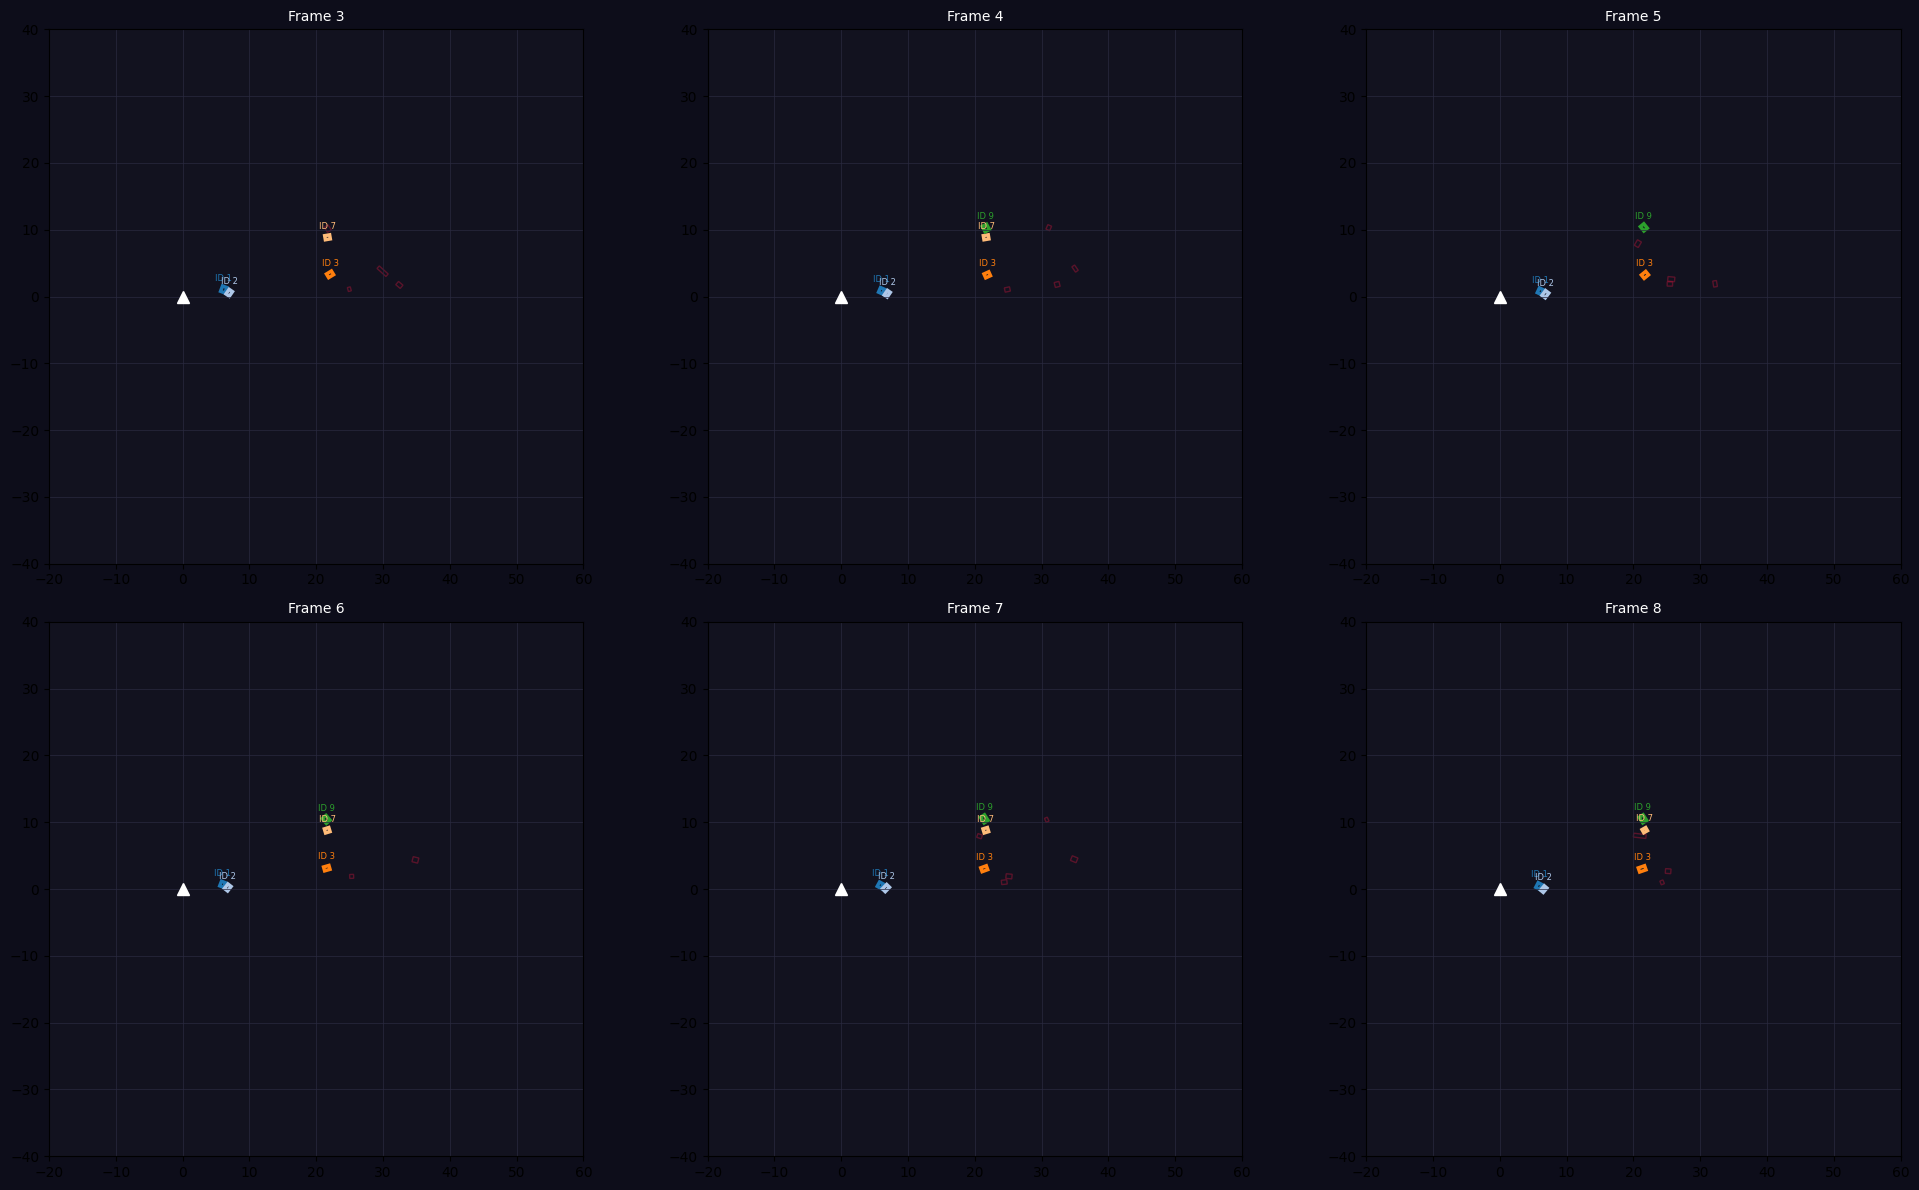

In [ ]:
# Step 12b: BEV Consecutive Frames — Show track IDs persisting across frames
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# RE-SYNC sequences_data to ensure it has the parsed keys added in the loading step
sequences_data = {}
for frame_data in detection_results:
    raw_fid = str(frame_data['frame_id']).zfill(8)
    seq_id = raw_fid[:4]
    if seq_id not in sequences_data: sequences_data[seq_id] = []
    sequences_data[seq_id].append(frame_data)

vis_seq = list(sequences_data.keys())[0]
seq_frame_list = sorted(sequences_data[vis_seq], key=lambda x: x['parsed_frame_num'])

# Find a window of 6 consecutive frames that have tracking results
N_SHOW = 6
vis_frames = []
for fd in seq_frame_list:
    fid = fd['frame_id']
    if len(tracking_results[vis_seq].get(fid, [])) > 0:
        vis_frames.append(fd)
    if len(vis_frames) >= N_SHOW:
        break

if len(vis_frames) < N_SHOW:
    vis_frames = seq_frame_list[:N_SHOW]

# Assign colors
all_track_ids = set()
for fd in vis_frames:
    for t in tracking_results[vis_seq].get(fd['frame_id'], []):
        all_track_ids.add(t['track_id'])

cmap = plt.get_cmap('tab20', max(len(all_track_ids), 20))
id_to_color = {tid: cmap(i % 20) for i, tid in enumerate(sorted(all_track_ids))}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0d0d1a')
axes_flat = axes.flatten()

for ax_i, fd in enumerate(vis_frames):
    ax = axes_flat[ax_i]
    frame_id = fd['frame_id']
    frame_num = fd['parsed_frame_num']
    ax.set_facecolor('#12121f')
    ax.set_aspect('equal')
    ax.grid(True, color='#2a2a40', linewidth=0.5)
    ax.set_title(f'Frame {frame_num}', color='white', fontsize=10)

    # Raw detections
    for det, name, score in zip(fd['boxes_lidar'], fd['name'], fd.get('score', np.ones(len(fd['name'])))):
        if score >= 0.5:
            draw_bev_box(ax, det[0], det[1], det[3], det[4], det[6], color='#ff1744', lw=1.0, alpha=0.3)

    # Tracks
    tracks = tracking_results[vis_seq].get(frame_id, [])
    for t in tracks:
        s, tid = t['state'], t['track_id']
        draw_bev_box(ax, s[0], s[1], s[3], s[4], s[6], color=id_to_color.get(tid, 'white'), lw=2.5, label=f"ID {tid}")

    ax.plot(0, 0, marker='^', color='white', ms=8)
    ax.set_xlim(-20, 60); ax.set_ylim(-40, 40)

plt.tight_layout()
plt.show()

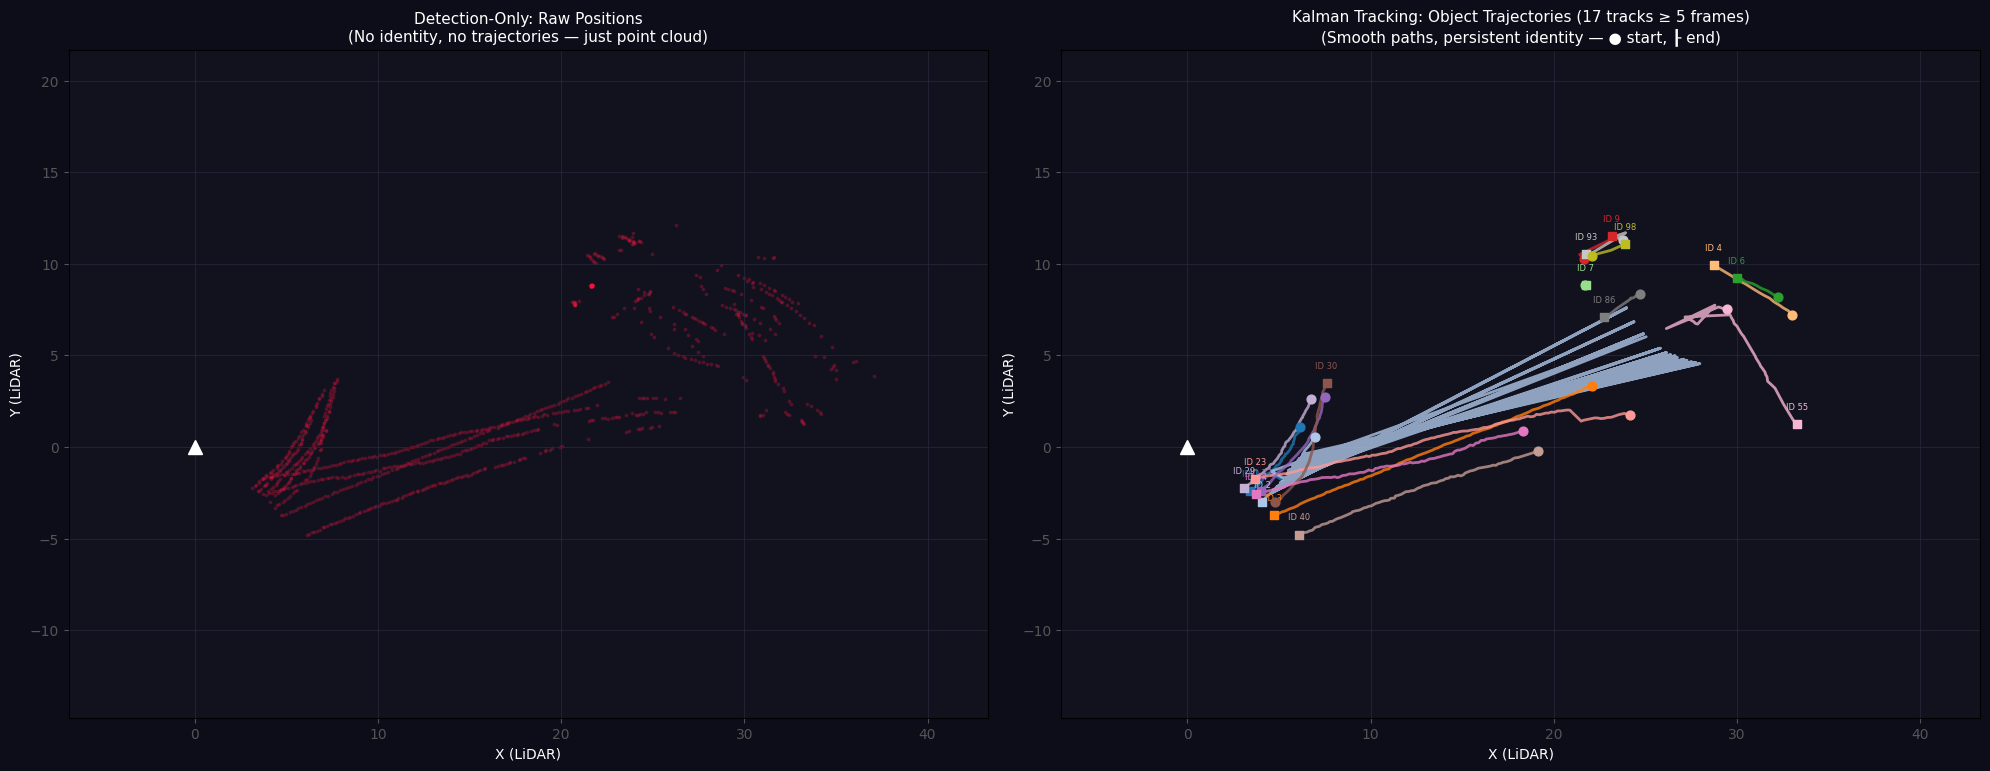


Total tracked objects: 18
Tracks with ≥ 5 frames (shown): 17

Left: Without tracking, detections are just a scatter cloud — no motion, no identity.
Right: With Kalman tracking, each object has a smooth trajectory with persistent ID.


In [ ]:
# Step 12c: BEV Trajectory Plot — Show smooth tracked paths vs Raw detections
# This demonstrates SMOOTH TRAJECTORIES and TEMPORAL CONSISTENCY
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

vis_seq = list(sequences_data.keys())[0]

# Collect trajectory histories: track_id -> list of (frame_num, x, y)
trajectory_history = {}
seq_frame_list = sorted(sequences_data[vis_seq], key=lambda x: x['parsed_frame_num'])

for fd in seq_frame_list:
    frame_id = fd['frame_id']
    frame_num = fd['parsed_frame_num']
    tracks = tracking_results[vis_seq].get(frame_id, [])
    for t in tracks:
        tid = t['track_id']
        s = t['state']
        if tid not in trajectory_history:
            trajectory_history[tid] = []
        trajectory_history[tid].append((frame_num, s[0], s[1]))

# Also collect raw detection positions for comparison (no identity)
raw_det_positions = []
for fd in seq_frame_list:
    frame_num = fd['parsed_frame_num']
    # Use generic 0.5 threshold if score_thresholds isn't fully initialized for all classes
    for det, name, score in zip(fd['boxes_lidar'], fd['name'], fd.get('score', np.ones(len(fd['boxes_lidar'])))):
        if score >= 0.5:
            raw_det_positions.append((frame_num, det[0], det[1]))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#0d0d1a')

# Left: Raw detections (no identity — just a scatter cloud)
ax1 = axes[0]
ax1.set_facecolor('#12121f')
if raw_det_positions:
    xs = [p[1] for p in raw_det_positions]
    ys = [p[2] for p in raw_det_positions]
    ax1.scatter(xs, ys, c='#ff1744', s=3, alpha=0.2)
ax1.plot(0, 0, marker='^', color='white', ms=10, zorder=10)
ax1.set_title("Detection-Only: Raw Positions\n(No identity, no trajectories — just point cloud)",
              color='white', fontsize=11)
ax1.set_xlabel("X (LiDAR)", color='white')
ax1.set_ylabel("Y (LiDAR)", color='white')
ax1.tick_params(colors='#555555')
ax1.set_aspect('equal')
ax1.grid(True, color='#2a2a40', linewidth=0.5)

# Right: Tracked trajectories (smooth paths with identity)
ax2 = axes[1]
ax2.set_facecolor('#12121f')
cmap = plt.get_cmap('tab20', max(len(trajectory_history), 20))
long_tracks = {tid: pts for tid, pts in trajectory_history.items() if len(pts) >= 5}

for i, (tid, points) in enumerate(sorted(long_tracks.items())):
    pts = sorted(points, key=lambda p: p[0])
    xs = [p[1] for p in pts]
    ys = [p[2] for p in pts]
    color = cmap(i % 20)
    ax2.plot(xs, ys, color=color, lw=2.0, alpha=0.8)
    ax2.scatter(xs[0], ys[0], color=color, s=40, marker='o', zorder=5)   # start
    ax2.scatter(xs[-1], ys[-1], color=color, s=40, marker='s', zorder=5)  # end
    ax2.text(xs[-1], ys[-1] + 0.8, f"ID {tid}", color=color, fontsize=6, ha='center')

ax2.plot(0, 0, marker='^', color='white', ms=10, zorder=10)
ax2.set_title(f"Kalman Tracking: Object Trajectories ({len(long_tracks)} tracks ≥ 5 frames)\n(Smooth paths, persistent identity — ● start, ┠ end)",
              color='white', fontsize=11)
ax2.set_xlabel("X (LiDAR)", color='white')
ax2.set_ylabel("Y (LiDAR)", color='white')
ax2.tick_params(colors='#555555')
ax2.set_aspect('equal')
ax2.grid(True, color='#2a2a40', linewidth=0.5)

# Match axis limits
all_x = [p[1] for pts in trajectory_history.values() for p in pts]
all_y = [p[2] for pts in trajectory_history.values() for p in pts]
if all_x and all_y:
    margin = 10
    xlim = (min(all_x) - margin, max(all_x) + margin)
    ylim = (min(all_y) - margin, max(all_y) + margin)
    ax1.set_xlim(xlim); ax1.set_ylim(ylim)
    ax2.set_xlim(xlim); ax2.set_ylim(ylim)

plt.tight_layout()
plt.show()
print(f"\nTotal tracked objects: {len(trajectory_history)}")
print(f"Tracks with ≥ 5 frames (shown): {len(long_tracks)}")
print("\nLeft: Without tracking, detections are just a scatter cloud — no motion, no identity.")
print("Right: With Kalman tracking, each object has a smooth trajectory with persistent ID.")